Predictive Forecasting of Care Load & Placement Demand

Notebook 04 – Feature Engineering

# Predictive Forecasting of Care Load & Placement Demand

# Notebook 04 – Feature Engineering

## Business Objective

The purpose of this notebook is to transform the cleaned operational dataset into a machine learning-ready dataset.

Feature engineering creates new predictive variables from historical observations that help forecasting models better capture trends, seasonality, momentum, and temporal relationships.

The engineered features generated in this notebook will be used in the subsequent predictive modeling notebooks to forecast future HHS care demand.

## Business Questions

This notebook aims to answer the following questions:

1. Which historical information best predicts future HHS Care occupancy?

2. Can previous day values improve forecasting accuracy?

3. Are weekly and monthly seasonal patterns present?

4. Can rolling averages smooth short-term fluctuations?

5. Which engineered features provide the strongest predictive signal?

6. Is the dataset ready for predictive modeling?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/HHS_UAC_Cleaned.csv")

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
719,2023-01-12,33.0,53.0,34.0,6566,436.0
718,2023-01-22,32.0,49.0,39.0,7122,227.0
717,2023-01-23,32.0,50.0,39.0,7280,181.0
716,2023-01-24,47.0,42.0,47.0,7433,175.0
715,2023-01-25,20.0,22.0,41.0,7538,180.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 719 to 0
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 33.9 KB


# Feature Engineering

In [5]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Quarter"] = df["Date"].dt.quarter

df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df["Day"] = df["Date"].dt.day

df["DayOfWeek"] = df["Date"].dt.dayofweek

df["Weekend"] = df["DayOfWeek"].isin([5,6]).astype(int)

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,Day,DayOfWeek,Weekend
719,2023-01-12,33.0,53.0,34.0,6566,436.0,2023,1,1,2,12,3,0
718,2023-01-22,32.0,49.0,39.0,7122,227.0,2023,1,1,3,22,6,1
717,2023-01-23,32.0,50.0,39.0,7280,181.0,2023,1,1,4,23,0,0
716,2023-01-24,47.0,42.0,47.0,7433,175.0,2023,1,1,4,24,1,0
715,2023-01-25,20.0,22.0,41.0,7538,180.0,2023,1,1,4,25,2,0


### Business Insight

Calendar-based features allow forecasting models to learn recurring weekly, monthly, quarterly, and yearly operational patterns.

These variables improve the model's ability to capture seasonality and demand cycles.

In [6]:
df["HHS_Lag_1"] = df["Children in HHS Care"].shift(1)

df["HHS_Lag_7"] = df["Children in HHS Care"].shift(7)

df["HHS_Lag_14"] = df["Children in HHS Care"].shift(14)

df["HHS_Lag_30"] = df["Children in HHS Care"].shift(30)

### Business Insight

Lag features provide historical context for forecasting models.

Past occupancy levels often serve as strong predictors of future care demand.

In [7]:
df["Rolling7"] = df["Children in HHS Care"].rolling(7).mean()

df["Rolling14"] = df["Children in HHS Care"].rolling(14).mean()

df["Rolling30"] = df["Children in HHS Care"].rolling(30).mean()

### Business Insight

Rolling averages smooth daily volatility and reveal underlying operational trends.

These features help forecasting algorithms distinguish long-term movement from short-term noise.

In [8]:
df["GrowthRate"] = df["Children in HHS Care"].pct_change()

### Business Insight

Growth rates measure the speed of operational change rather than absolute occupancy.

Rapid increases may indicate emerging resource pressures requiring proactive planning.

In [9]:
df["Target"] = df["Children in HHS Care"].shift(-1)

### Business Insight

The target variable represents the next day's HHS care population, enabling supervised learning models to predict future occupancy.

In [10]:
df.isnull().sum()

Date                                                0
Children apprehended and placed in CBP custody*     0
Children in CBP custody                             0
Children transferred out of CBP custody             0
Children in HHS Care                                0
Children discharged from HHS Care                   0
Year                                                0
Month                                               0
Quarter                                             0
Week                                                0
Day                                                 0
DayOfWeek                                           0
Weekend                                             0
HHS_Lag_1                                           1
HHS_Lag_7                                           7
HHS_Lag_14                                         14
HHS_Lag_30                                         30
Rolling7                                            6
Rolling14                   

In [11]:
df = df.dropna()

df.shape

(689, 22)

### Business Insight

Missing values introduced by lag and rolling calculations are expected and are removed to ensure reliable model training.

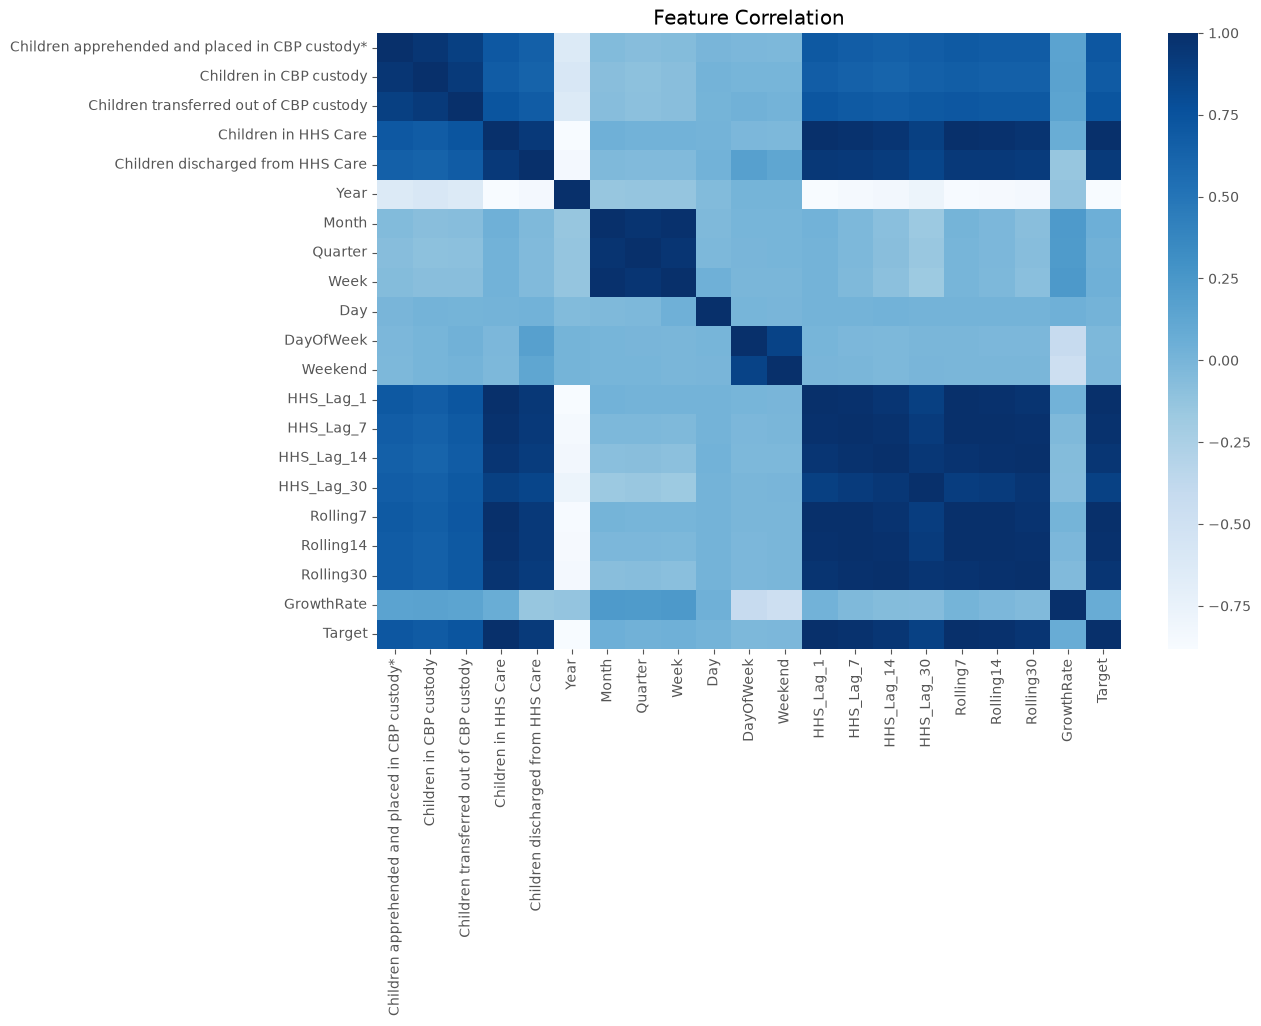

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            cmap="Blues",
            annot=False)

plt.title("Feature Correlation")

plt.show()

### Business Insight

The correlation matrix helps identify which engineered variables contain the strongest predictive information and highlights redundancy among features.

In [13]:
df.to_csv("../data/processed/HHS_UAC_Feature_Engineered.csv", index=False)

# Feature Engineering Summary

## Key Features Created

- Calendar Features
    - Year
    - Month
    - Quarter
    - Week
    - Day
    - DayOfWeek
    - Weekend

- Lag Features
    - 1-day
    - 7-day
    - 14-day
    - 30-day

- Rolling Statistics
    - 7-day Average
    - 14-day Average
    - 30-day Average

- Growth Rate

- Target Variable

The resulting dataset is fully prepared for predictive modeling and contains both historical and temporal information required by machine learning forecasting algorithms.